# Baby Cry Sense Dataset -- Audio Preprocessing Pipeline

## Purpose

This notebook transforms the raw audio dataset into a clean,
standardized collection of audio files ready for feature
engineering. Every decision is justified by findings from
01_EDA.ipynb.

## What This Notebook Does (Preprocessing)

1. Set parameters justified by EDA findings
2. Build metadata inventory of all raw files
3. Validate raw files before any processing
4. Convert non-.wav files to .wav format
5. Resample all files to a uniform sample rate
6. Normalize duration (pad or truncate)
7. Normalize amplitude to consistent peak level
8. Run quality checks and remove bad samples
9. Augment minority classes to address imbalance
10. Save cleaned audio and manifest CSV
11. Verify saved files by reading them back


## Section 1 -- Imports and Target Parameters

In [171]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from tqdm import tqdm
from collections import Counter
import shutil
import json
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All libraries imported successfully.


In [172]:
# =============================================================
# TARGET PARAMETERS
# =============================================================

TARGET_SR = 22050
TARGET_DURATION = 7.0
TARGET_SAMPLES = int(TARGET_SR * TARGET_DURATION)  # 154350
AMPLITUDE_THRESHOLD = 0.01
EPSILON = 1e-9

# Augmentation settings
AUGMENT_MINORITY = True
MIN_SAMPLES_PER_CLASS = 130

# =============================================================
# PATH CONFIGURATION
# =============================================================
from google.colab import drive
drive.mount('/content/drive')

RAW_DATASET_PATH = "/content/drive/MyDrive/BabyCryDataset"

PROCESSED_DIR = "data/processed/audio_clean/"
MANIFEST_PATH = "data/processed/clean_manifest.csv"
TEMP_DIR = "data/temp_converted/"
PARAMS_PATH = "data/processed/preprocessing_params.json"

# =============================================================
# VERIFY PATH BEFORE PROCEEDING
# =============================================================
if not os.path.exists(RAW_DATASET_PATH):
    raise FileNotFoundError(
        f"Path does not exist: {RAW_DATASET_PATH}\n"
        f"Run os.listdir('/content/drive/MyDrive/') "
        f"to find the correct path."
    )

contents = os.listdir(RAW_DATASET_PATH)
dirs_found = [d for d in contents
              if os.path.isdir(os.path.join(RAW_DATASET_PATH, d))]
print(f"RAW_DATASET_PATH: {RAW_DATASET_PATH}")
print(f"Subdirectories found: {sorted(dirs_found)}")
print(f"Count: {len(dirs_found)}")

if len(dirs_found) == 0:
    raise ValueError(
        f"No subdirectories found in {RAW_DATASET_PATH}. "
        f"Check your folder structure."
    )
else:
    print(f"\nPath looks correct. Found {len(dirs_found)} category folders.")

print(f"\nTARGET PARAMETERS")
print(f"=" * 55)
print(f"  TARGET_SR:            {TARGET_SR} Hz")
print(f"  TARGET_DURATION:      {TARGET_DURATION} s")
print(f"  TARGET_SAMPLES:       {TARGET_SAMPLES}")
print(f"  AMPLITUDE_THRESHOLD:  {AMPLITUDE_THRESHOLD}")
print(f"  AUGMENT_MINORITY:     {AUGMENT_MINORITY}")
print(f"  MIN_SAMPLES_PER_CLASS:{MIN_SAMPLES_PER_CLASS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RAW_DATASET_PATH: /content/drive/MyDrive/BabyCryDataset
Subdirectories found: ['belly pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'lonely', 'scared', 'tired']
Count: 8

Path looks correct. Found 8 category folders.

TARGET PARAMETERS
  TARGET_SR:            22050 Hz
  TARGET_DURATION:      7.0 s
  TARGET_SAMPLES:       154350
  AMPLITUDE_THRESHOLD:  0.01
  AUGMENT_MINORITY:     True
  MIN_SAMPLES_PER_CLASS:130


### Parameter Justifications from EDA

**TARGET_SR = 22050 Hz**

EDA found two sample rate populations: 8000 Hz (majority, from
original Donate-A-Cry mobile app) and 44100 Hz (minority, likely
re-recorded or augmented). The cross-tabulation showed this
distribution is correlated with class labels, meaning a model
could learn recording-quality artifacts instead of cry patterns.

22050 Hz was chosen because:
- Sits between both source rates, minimizing distortion
- Preserves frequencies up to 11025 Hz (covers full infant cry range)
- Standard default in librosa and audio ML pipelines

Important limitation: upsampling 8000 Hz files to 22050 Hz does
NOT recover frequency content above 4000 Hz. Those files will
have empty spectrum above 4000 Hz. This is an inherent dataset
limitation.

**TARGET_DURATION = 7.0 seconds**

EDA duration analysis showed mean duration of 6.78 seconds and
95th percentile of 7.02 seconds. TARGET_DURATION = 7.0 seconds
was chosen to retain 94.8% of files completely intact with only
59 files requiring trimming.

This duration was chosen because:
1. It retains nearly all audio content without truncation
2. It captures multiple complete cry cycles (infant cry bursts
   typically last 1-2 seconds each), giving the model sufficient
   temporal context
3. Post-padding with zeros is preferred because infant cry content
   is front-loaded -- the meaningful acoustic event starts at the
   beginning of the clip

**AMPLITUDE_THRESHOLD = 0.01**

Files with peak amplitude below 0.01 after normalization are
effectively silent and contain no usable cry information. These
are flagged for removal during quality control.

**MIN_SAMPLES_PER_CLASS = 130**

EDA found imbalance ratio of approximately 16:1 (hungry 397 vs
lonely 25). Setting minimum to 130 brings minority classes
(lonely 25, scared 33) closer to the median class size without
overwhelming the dataset with synthetic samples.

In [173]:
# Create all output directories
for directory in [PROCESSED_DIR, TEMP_DIR, os.path.dirname(MANIFEST_PATH)]:
    os.makedirs(directory, exist_ok=True)
    print(f"  Directory ready: {directory}")

  Directory ready: data/processed/audio_clean/
  Directory ready: data/temp_converted/
  Directory ready: data/processed


## Section 2 -- Build Raw Dataset Inventory

Walk through the raw dataset and build a complete metadata table
before any processing begins. This gives us the baseline counts
to compare against after each step.

In [174]:
raw_records = []

for category_name in sorted(os.listdir(RAW_DATASET_PATH)):
    category_path = os.path.join(RAW_DATASET_PATH, category_name)
    if not os.path.isdir(category_path):
        continue
    for file_name in os.listdir(category_path):
        file_path = os.path.join(category_path, file_name)
        if not os.path.isfile(file_path):
            continue
        file_ext = os.path.splitext(file_name)[1].lower()
        file_size_kb = os.path.getsize(file_path) / 1024.0
        raw_records.append({
            'file_path': file_path,
            'file_name': file_name,
            'category': category_name,
            'format': file_ext,
            'file_size_KB': round(file_size_kb, 2)
        })

df_raw = pd.DataFrame(raw_records)

print(f"RAW DATASET INVENTORY")
print(f"=" * 55)
print(f"  Total files:  {len(df_raw)}")
print(f"  Categories:   {sorted(df_raw['category'].unique())}")
print(f"\n  Files per category:")
for cat, count in df_raw['category'].value_counts().sort_index().items():
    print(f"    {cat:>15s}: {count}")
print(f"\n  File formats:")
for fmt, count in df_raw['format'].value_counts().items():
    print(f"    {fmt:>6s}: {count}")

RAW DATASET INVENTORY
  Total files:  1126
  Categories:   ['belly pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'lonely', 'scared', 'tired']

  Files per category:
         belly pain: 133
            burping: 124
           cold_hot: 130
         discomfort: 142
             hungry: 397
             lonely: 25
             scared: 33
              tired: 142

  File formats:
      .wav: 1039
      .3gp: 72
      .ogg: 8
      .mp3: 7


## Section 3 -- Validate Raw Files

Before any processing, check every file to confirm it can be
loaded and contains actual audio content. This catches:
- Corrupted files that cannot be read
- Empty files with zero samples
- Silent files with no audible content

Files failing validation are removed before the pipeline
begins, so downstream steps never encounter bad data.

In [175]:
valid_records = []
invalid_records = []

for idx, row in tqdm(df_raw.iterrows(), total=len(df_raw),
                     desc="Validating raw files"):
    try:
        # Attempt to load first 1 second to check readability
        y, sr = librosa.load(row['file_path'], sr=None, duration=1.0)

        if len(y) == 0:
            invalid_records.append({
                'file': row['file_path'],
                'category': row['category'],
                'reason': 'Empty file (0 samples)'
            })
            continue

        if np.max(np.abs(y)) < 1e-8:
            invalid_records.append({
                'file': row['file_path'],
                'category': row['category'],
                'reason': 'Completely silent (max amplitude < 1e-8)'
            })
            continue

        if np.any(np.isnan(y)) or np.any(np.isinf(y)):
            invalid_records.append({
                'file': row['file_path'],
                'category': row['category'],
                'reason': 'Contains NaN or Inf values'
            })
            continue

        valid_records.append({
            'file_path': row['file_path'],
            'file_name': row['file_name'],
            'category': row['category'],
            'format': row['format'],
            'file_size_KB': row['file_size_KB'],
            'native_sr': sr
        })

    except Exception as e:
        invalid_records.append({
            'file': row['file_path'],
            'category': row['category'],
            'reason': str(e)
        })

df_valid = pd.DataFrame(valid_records)

print(f"\nRAW VALIDATION RESULTS")
print(f"=" * 55)
print(f"  Valid files:   {len(df_valid)}")
print(f"  Invalid files: {len(invalid_records)}")

if invalid_records:
    print(f"\n  Invalid file details:")
    for rec in invalid_records:
        print(f"    [{rec['category']}] {rec['file']}")
        print(f"      Reason: {rec['reason']}")

Validating raw files: 100%|██████████| 1126/1126 [00:11<00:00, 98.30it/s] 


RAW VALIDATION RESULTS
  Valid files:   1126
  Invalid files: 0


## Section 4 -- File Format Conversion

EDA identified 1039 .wav files, 8 .ogg files, and 7 other formats.
All non-.wav files are converted to .wav using librosa for loading
and soundfile for saving. Files already in .wav format are unchanged.

In [176]:
non_wav = df_valid[df_valid['format'] != '.wav'].copy()
wav_files = df_valid[df_valid['format'] == '.wav'].copy()

print("FORMAT CONVERSION")
print("=" * 55)
print(f"  .wav files (no conversion needed): {len(wav_files)}")
print(f"  Non-.wav files (need conversion):  {len(non_wav)}")

if len(non_wav) > 0:
    print(f"\n  Files to convert:")
    for _, row in non_wav.iterrows():
        print(f"    [{row['format']}] {row['category']}/{row['file_name']}")

FORMAT CONVERSION
  .wav files (no conversion needed): 1039
  Non-.wav files (need conversion):  87

  Files to convert:
    [.3gp] belly pain/bp-18.3gp
    [.3gp] belly pain/bp-2.3gp
    [.3gp] belly pain/bp-17.3gp
    [.3gp] belly pain/bp-21.3gp
    [.3gp] belly pain/bp-22.3gp
    [.3gp] belly pain/bp-23.3gp
    [.3gp] burping/bu-4 - Copy.3gp
    [.3gp] burping/bu-16.3gp
    [.3gp] burping/bu-13.3gp
    [.3gp] burping/bu-16 - Copy.3gp
    [.3gp] burping/bu-13 - Copy.3gp
    [.3gp] burping/bu-4.3gp
    [.ogg] cold_hot/61c.ogg
    [.ogg] cold_hot/68c.ogg
    [.ogg] cold_hot/65c.ogg
    [.ogg] cold_hot/64c.ogg
    [.ogg] cold_hot/67c.ogg
    [.ogg] cold_hot/66c.ogg
    [.ogg] cold_hot/63c.ogg
    [.ogg] cold_hot/62c.ogg
    [.3gp] cold_hot/ch-10 - Copy.3gp
    [.3gp] cold_hot/ch-4.3gp
    [.3gp] cold_hot/ch-5.3gp
    [.3gp] cold_hot/ch-5 - Copy (2).3gp
    [.3gp] cold_hot/ch-5 - Copy.3gp
    [.3gp] cold_hot/ch-6 - Copy (2).3gp
    [.3gp] cold_hot/ch-6 - Copy.3gp
    [.3gp] cold_hot/ch-9

In [177]:
converted = []
conversion_failures = []

if len(non_wav) > 0:
    for idx, row in non_wav.iterrows():
        try:
            y, sr = librosa.load(row['file_path'], sr=None, mono=True)

            base_name = os.path.splitext(row['file_name'])[0]
            new_name = base_name + '.wav'
            cat_dir = os.path.join(TEMP_DIR, row['category'])
            os.makedirs(cat_dir, exist_ok=True)
            new_path = os.path.join(cat_dir, new_name)

            sf.write(new_path, y, sr)

            converted.append({
                'file_path': new_path,
                'file_name': new_name,
                'category': row['category'],
                'format': '.wav',
                'file_size_KB': round(os.path.getsize(new_path) / 1024, 2),
                'native_sr': sr
            })
            print(f"    Converted: {row['file_name']} -> {new_name}")

        except Exception as e:
            conversion_failures.append({
                'file': row['file_path'],
                'error': str(e)
            })
            print(f"    FAILED: {row['file_name']} -- {e}")

    print(f"\n  Converted: {len(converted)}, Failed: {len(conversion_failures)}")
else:
    print("  No conversion needed.")

    Converted: bp-18.3gp -> bp-18.wav
    Converted: bp-2.3gp -> bp-2.wav
    Converted: bp-17.3gp -> bp-17.wav
    Converted: bp-21.3gp -> bp-21.wav
    Converted: bp-22.3gp -> bp-22.wav
    Converted: bp-23.3gp -> bp-23.wav
    Converted: bu-4 - Copy.3gp -> bu-4 - Copy.wav
    Converted: bu-16.3gp -> bu-16.wav
    Converted: bu-13.3gp -> bu-13.wav
    Converted: bu-16 - Copy.3gp -> bu-16 - Copy.wav
    Converted: bu-13 - Copy.3gp -> bu-13 - Copy.wav
    Converted: bu-4.3gp -> bu-4.wav
    Converted: 61c.ogg -> 61c.wav
    Converted: 68c.ogg -> 68c.wav
    Converted: 65c.ogg -> 65c.wav
    Converted: 64c.ogg -> 64c.wav
    Converted: 67c.ogg -> 67c.wav
    Converted: 66c.ogg -> 66c.wav
    Converted: 63c.ogg -> 63c.wav
    Converted: 62c.ogg -> 62c.wav
    Converted: ch-10 - Copy.3gp -> ch-10 - Copy.wav
    Converted: ch-4.3gp -> ch-4.wav
    Converted: ch-5.3gp -> ch-5.wav
    Converted: ch-5 - Copy (2).3gp -> ch-5 - Copy (2).wav
    Converted: ch-5 - Copy.3gp -> ch-5 - Copy.wav
    

In [178]:
# Build unified file list pointing only to .wav files
unified_records = []

for _, row in wav_files.iterrows():
    unified_records.append(row.to_dict())

for rec in converted:
    unified_records.append(rec)

df_unified = pd.DataFrame(unified_records)

print(f"Unified file list: {len(df_unified)} files (all .wav)")
print(f"  Original .wav: {len(wav_files)}")
print(f"  Converted:     {len(converted)}")
print(f"  Lost:          {len(conversion_failures)}")

Unified file list: 1126 files (all .wav)
  Original .wav: 1039
  Converted:     87
  Lost:          0


## Section 5 -- Resampling

Resample all files to TARGET_SR (22050 Hz).

**Resampling math:**

Resampling from sr1 to sr2 applies a low-pass filter at
min(sr1, sr2) / 2 Hz to prevent aliasing, then interpolates
(if upsampling) or decimates (if downsampling) the signal.

- 8000 Hz to 22050 Hz (upsampling): low-pass filter at 4000 Hz.
  New samples are interpolated but NO frequency content above
  4000 Hz is created. The upsampled spectrum is empty above 4000 Hz.

- 44100 Hz to 22050 Hz (downsampling): low-pass filter at 11025 Hz.
  Content above 11025 Hz is removed. For infant cries this loses
  nothing meaningful.

- Files already at 22050 Hz pass through unchanged.

In [179]:
# Sample rate distribution BEFORE resampling
print("SAMPLE RATE DISTRIBUTION BEFORE RESAMPLING")
print("=" * 55)
sr_dist = df_unified['native_sr'].value_counts().sort_index()
for rate, count in sr_dist.items():
    pct = count / len(df_unified) * 100
    status = "no change" if rate == TARGET_SR else "will resample"
    print(f"  {rate:>6.0f} Hz: {count:>4d} files ({pct:5.1f}%) -- {status}")

# Cross-tabulation: critical EDA finding
print(f"\n  Sample rate by category:")
print(pd.crosstab(df_unified['category'],
                  df_unified['native_sr']).to_string())

SAMPLE RATE DISTRIBUTION BEFORE RESAMPLING
    8000 Hz:  988 files ( 87.7%) -- will resample
   44100 Hz:  138 files ( 12.3%) -- will resample

  Sample rate by category:
native_sr   8000   44100
category                
belly pain     92     41
burping        87     37
cold_hot      115     15
discomfort    139      3
hungry        397      0
lonely         14     11
scared          6     27
tired         138      4


In [180]:
resampled_data = []
resample_log = []

for idx, row in tqdm(df_unified.iterrows(), total=len(df_unified),
                     desc="Resampling"):
    try:
        y, sr = librosa.load(row['file_path'], sr=None, mono=True)
        original_sr = sr

        if sr != TARGET_SR:
            y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
            action = f"{original_sr}->{TARGET_SR}"
        else:
            action = "unchanged"

        resampled_data.append({
            'file_name': row['file_name'],
            'category': row['category'],
            'original_sr': original_sr,
            'audio': y,
            'duration_sec': len(y) / TARGET_SR
        })

        resample_log.append({
            'file_name': row['file_name'],
            'category': row['category'],
            'original_sr': original_sr,
            'action': action,
            'samples_before': len(librosa.load(row['file_path'],
                                               sr=None)[0]) if action != "unchanged" else len(y),
            'samples_after': len(y),
            'duration_sec': round(len(y) / TARGET_SR, 3)
        })

    except Exception as e:
        print(f"  Failed: {row['file_path']} -- {e}")

df_resample = pd.DataFrame(resample_log)
print(f"\nResampled: {len(resampled_data)} files, all at {TARGET_SR} Hz")

Resampling: 100%|██████████| 1126/1126 [00:11<00:00, 98.28it/s] 


Resampled: 1126 files, all at 22050 Hz


In [181]:
# Resampling summary
print("RESAMPLING SUMMARY")
print("=" * 55)
action_counts = df_resample['action'].value_counts()
for action, count in action_counts.items():
    pct = count / len(df_resample) * 100
    print(f"  {action:>20s}: {count:>4d} files ({pct:.1f}%)")

print(f"\n  All {len(resampled_data)} files now at {TARGET_SR} Hz")

RESAMPLING SUMMARY
           8000->22050:  988 files (87.7%)
          44100->22050:  138 files (12.3%)

  All 1126 files now at 22050 Hz


## Section 6 -- Duration Normalization

Standardize all clips to exactly TARGET_DURATION (4.0 seconds)
which equals TARGET_SAMPLES (88200 samples) at TARGET_SR (22050 Hz).

**Rules:**
- Shorter than target: post-pad with zeros (append silence at end)
- Longer than target: trim to first TARGET_SAMPLES samples

**Why post-padding (not pre-padding):**

Infant cry content is front-loaded. The caregiver starts recording
when the cry begins, so the meaningful acoustic event is at the
start of the clip. Post-padding preserves temporal alignment of
cry onset across all clips, which matters for CNN pattern learning.

**Why zero-padding (not reflection or wrapping):**

Zeros represent silence. Silence does not introduce misleading
acoustic content. Reflection padding would create artificial
spectral artifacts. Wrapping would create discontinuities.

In [182]:
# Duration distribution BEFORE normalization
durations_before = [item['duration_sec'] for item in resampled_data]
dur_series = pd.Series(durations_before)

print("DURATION STATISTICS BEFORE NORMALIZATION")
print("=" * 55)
print(f"  Count:    {len(dur_series)}")
print(f"  Mean:     {dur_series.mean():.2f} s")
print(f"  Median:   {dur_series.median():.2f} s")
print(f"  Std:      {dur_series.std():.2f} s")
print(f"  Min:      {dur_series.min():.2f} s")
print(f"  Max:      {dur_series.max():.2f} s")
print(f"  Target:   {TARGET_DURATION} s ({TARGET_SAMPLES} samples)")
print(f"\n  Will be padded:  {(dur_series < TARGET_DURATION).sum()}")
print(f"  Already exact:   {((dur_series - TARGET_DURATION).abs() < 0.001).sum()}")
print(f"  Will be trimmed: {(dur_series > TARGET_DURATION).sum()}")

# Percentiles for reference
print(f"\n  Duration percentiles:")
for p in [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"    {int(p*100):>3d}th: {dur_series.quantile(p):.2f} s")

DURATION STATISTICS BEFORE NORMALIZATION
  Count:    1126
  Mean:     6.78 s
  Median:   6.92 s
  Std:      0.53 s
  Min:      4.13 s
  Max:      8.73 s
  Target:   7.0 s (154350 samples)

  Will be padded:  702
  Already exact:   365
  Will be trimmed: 59

  Duration percentiles:
     25th: 6.84 s
     50th: 6.92 s
     75th: 7.00 s
     90th: 7.00 s
     95th: 7.02 s
     99th: 7.06 s


In [183]:
duration_fixed = []
duration_log = []

for item in tqdm(resampled_data, desc="Normalizing duration"):
    y = item['audio']
    original_samples = len(y)
    original_dur = original_samples / TARGET_SR

    if original_samples < TARGET_SAMPLES:
        padding = TARGET_SAMPLES - original_samples
        y_fixed = np.pad(y, (0, padding), mode='constant', constant_values=0)
        action = 'padded'
        diff = padding / TARGET_SR

    elif original_samples > TARGET_SAMPLES:
        y_fixed = y[:TARGET_SAMPLES]
        action = 'trimmed'
        diff = (original_samples - TARGET_SAMPLES) / TARGET_SR

    else:
        y_fixed = y.copy()
        action = 'unchanged'
        diff = 0.0

    duration_fixed.append({
        'file_name': item['file_name'],
        'category': item['category'],
        'original_sr': item['original_sr'],
        'audio': y_fixed
    })

    duration_log.append({
        'file_name': item['file_name'],
        'category': item['category'],
        'original_duration': round(original_dur, 3),
        'action': action,
        'diff_seconds': round(diff, 3)
    })

df_dur_log = pd.DataFrame(duration_log)
print(f"\nDuration normalization complete: {len(duration_fixed)} files")

Normalizing duration: 100%|██████████| 1126/1126 [00:00<00:00, 5272.17it/s]


Duration normalization complete: 1126 files


In [184]:
# Duration normalization summary
print("DURATION NORMALIZATION SUMMARY")
print("=" * 55)
for action, count in df_dur_log['action'].value_counts().items():
    pct = count / len(df_dur_log) * 100
    print(f"  {action:>10s}: {count:>4d} files ({pct:.1f}%)")

padded = df_dur_log[df_dur_log['action'] == 'padded']
if len(padded) > 0:
    print(f"\n  Padding: mean {padded['diff_seconds'].mean():.2f}s, "
          f"max {padded['diff_seconds'].max():.2f}s")

trimmed = df_dur_log[df_dur_log['action'] == 'trimmed']
if len(trimmed) > 0:
    print(f"  Trimming: mean {trimmed['diff_seconds'].mean():.2f}s, "
          f"max {trimmed['diff_seconds'].max():.2f}s")

print(f"\n  Per-category breakdown:")
print(pd.crosstab(df_dur_log['category'],
                  df_dur_log['action']).to_string())

DURATION NORMALIZATION SUMMARY
      padded:  702 files (62.3%)
   unchanged:  365 files (32.4%)
     trimmed:   59 files (5.2%)

  Padding: mean 0.37s, max 2.87s
  Trimming: mean 0.25s, max 1.73s

  Per-category breakdown:
action      padded  trimmed  unchanged
category                              
belly pain      75        2         56
burping        113        5          6
cold_hot        88        2         40
discomfort      70       15         57
hungry         230       25        142
lonely          25        0          0
scared          28        5          0
tired           73        5         64


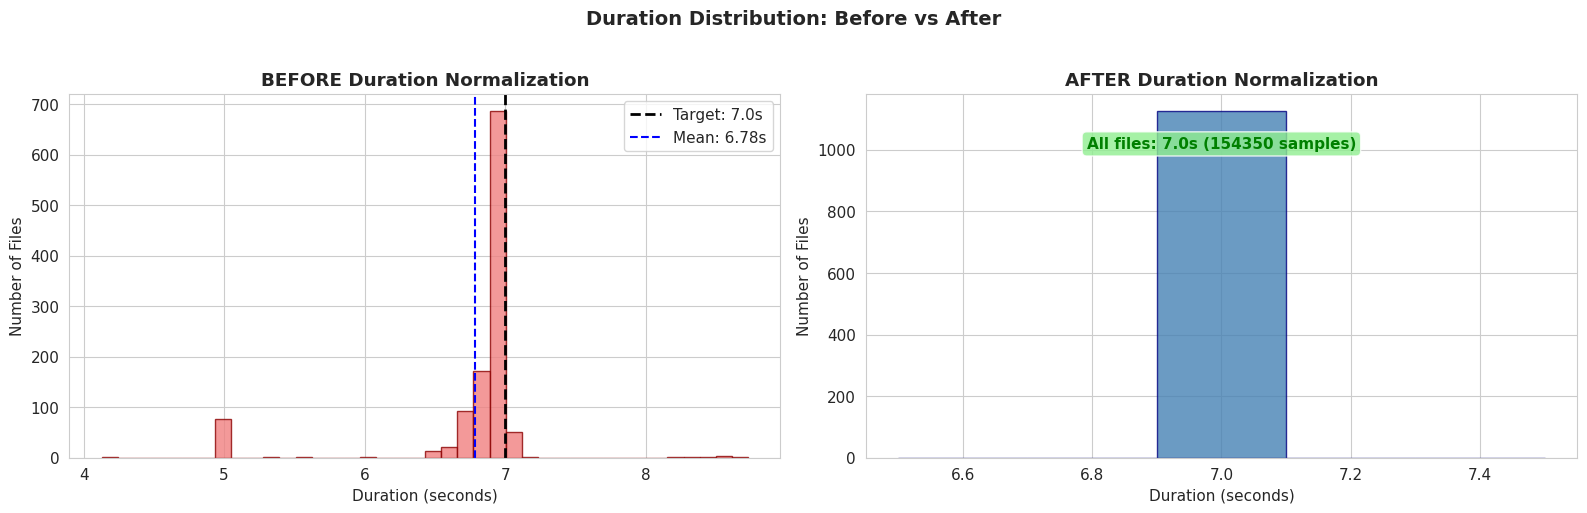

Verified: all 1126 files = 154350 samples (7.0s)


In [185]:
# Side-by-side histograms: BEFORE vs AFTER
durations_after = [len(item['audio']) / TARGET_SR for item in duration_fixed]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(durations_before, bins=40, color='lightcoral',
             edgecolor='darkred', alpha=0.8)
axes[0].axvline(TARGET_DURATION, color='black', linestyle='--',
                linewidth=2, label=f'Target: {TARGET_DURATION}s')
axes[0].axvline(np.mean(durations_before), color='blue', linestyle='--',
                linewidth=1.5,
                label=f'Mean: {np.mean(durations_before):.2f}s')
axes[0].set_title('BEFORE Duration Normalization', fontweight='bold')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Number of Files')
axes[0].legend()

axes[1].hist(durations_after, bins=5, color='steelblue',
             edgecolor='navy', alpha=0.8)
axes[1].set_title('AFTER Duration Normalization', fontweight='bold')
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_ylabel('Number of Files')

unique_after = set([round(d, 4) for d in durations_after])
if len(unique_after) == 1:
    axes[1].text(0.5, 0.85,
                 f'All files: {TARGET_DURATION}s ({TARGET_SAMPLES} samples)',
                 transform=axes[1].transAxes, ha='center', fontsize=11,
                 fontweight='bold', color='green',
                 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.suptitle('Duration Distribution: Before vs After',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Hard assertion
all_lengths = [len(item['audio']) for item in duration_fixed]
assert all(l == TARGET_SAMPLES for l in all_lengths), \
    "Not all files have correct length"
print(f"Verified: all {len(duration_fixed)} files = "
      f"{TARGET_SAMPLES} samples ({TARGET_DURATION}s)")

## Section 7 -- Amplitude Normalization

Normalize each clip so its peak amplitude equals exactly 1.0.

**Formula:**

audio = audio/(max(|audio|)+ epsilon)

**Why peak normalization:**
- Removes variation caused by different microphone gains and
  recording distances
- Ensures all clips occupy the same dynamic range
- The epsilon (1e-9) prevents division by zero on silent clips

**Silent file flagging:**
After computing peak amplitude, any file with original peak
below AMPLITUDE_THRESHOLD (0.01) is flagged. These files have
negligible acoustic content and are candidates for removal
in the quality check step.

In [186]:
amplitude_data = []
amplitude_log = []
flagged_silent = []

for item in tqdm(duration_fixed, desc="Normalizing amplitude"):
    y = item['audio'].copy()
    peak_before = float(np.max(np.abs(y)))

    y_norm = y / (peak_before + EPSILON)
    peak_after = float(np.max(np.abs(y_norm)))

    is_silent = peak_before < AMPLITUDE_THRESHOLD

    amplitude_data.append({
        'file_name': item['file_name'],
        'category': item['category'],
        'original_sr': item['original_sr'],
        'audio': y_norm,
        'peak_before': peak_before,
        'is_silent': is_silent
    })

    amplitude_log.append({
        'file_name': item['file_name'],
        'category': item['category'],
        'peak_before': round(peak_before, 6),
        'peak_after': round(peak_after, 6),
        'is_silent': is_silent
    })

    if is_silent:
        flagged_silent.append({
            'file_name': item['file_name'],
            'category': item['category'],
            'peak': round(peak_before, 6)
        })

df_amp_log = pd.DataFrame(amplitude_log)
print(f"\nAmplitude normalization complete: {len(amplitude_data)} files")

Normalizing amplitude: 100%|██████████| 1126/1126 [00:00<00:00, 4235.85it/s]


Amplitude normalization complete: 1126 files


In [187]:
print("AMPLITUDE NORMALIZATION REPORT")
print("=" * 55)
print(f"  Total processed: {len(amplitude_data)}")
print(f"  Peak range before: [{df_amp_log['peak_before'].min():.6f}, "
      f"{df_amp_log['peak_before'].max():.6f}]")
print(f"  Peak range after:  all at ~1.0")
print(f"\n  Near-silent files (peak < {AMPLITUDE_THRESHOLD}): "
      f"{len(flagged_silent)}")

if flagged_silent:
    print(f"\n  Flagged files:")
    for f in flagged_silent:
        print(f"    [{f['category']:>13s}] {f['file_name']} "
              f"(peak: {f['peak']:.6f})")
else:
    print(f"  No silent files detected.")

AMPLITUDE NORMALIZATION REPORT
  Total processed: 1126
  Peak range before: [0.004278, 1.745160]
  Peak range after:  all at ~1.0

  Near-silent files (peak < 0.01): 1

  Flagged files:
    [       lonely] 3f61124d-d02c-47dd-a009-44e97e60c4ca-1430761203697-1.7-f-72-lo.wav (peak: 0.004278)


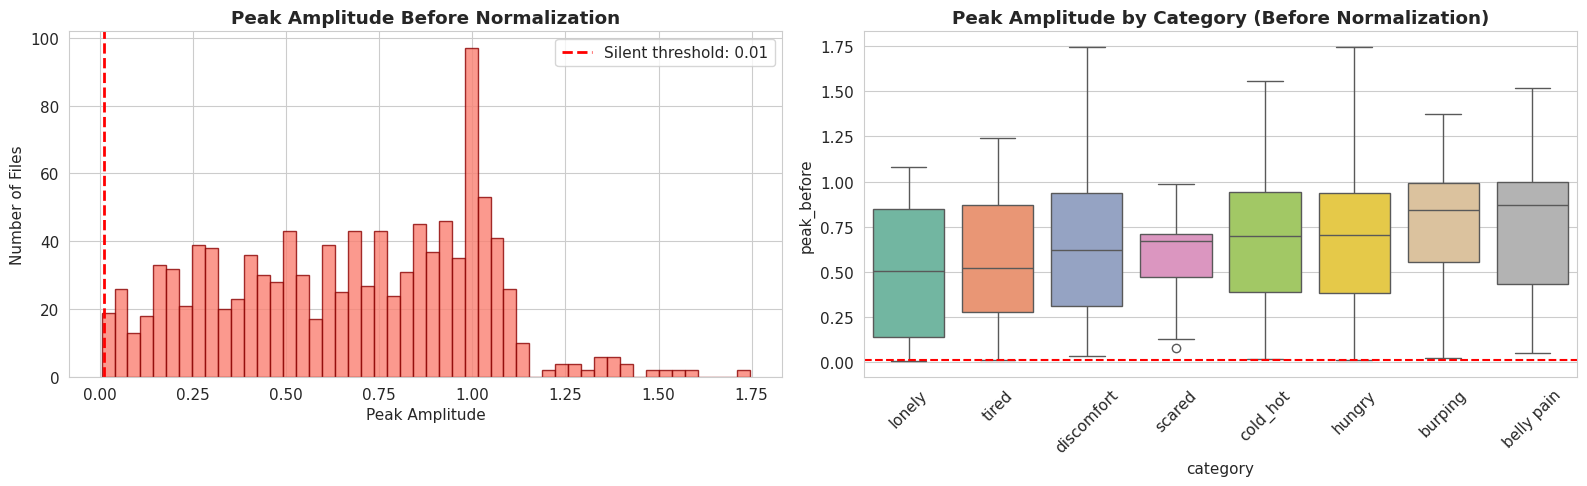

In [188]:
# Visualize peak amplitudes before normalization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_amp_log['peak_before'], bins=50,
             color='salmon', edgecolor='darkred', alpha=0.8)
axes[0].axvline(AMPLITUDE_THRESHOLD, color='red', linestyle='--',
                linewidth=2, label=f'Silent threshold: {AMPLITUDE_THRESHOLD}')
axes[0].set_title('Peak Amplitude Before Normalization', fontweight='bold')
axes[0].set_xlabel('Peak Amplitude')
axes[0].set_ylabel('Number of Files')
axes[0].legend()

order = df_amp_log.groupby('category')['peak_before'].median().sort_values().index
sns.boxplot(data=df_amp_log, x='category', y='peak_before',
            palette='Set2', order=order, ax=axes[1])
axes[1].axhline(AMPLITUDE_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Peak Amplitude by Category (Before Normalization)',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Section 8 -- Quality Check and Bad Sample Removal

Every processed clip is checked against four criteria:

1. Shape is exactly (88200,) -- TARGET_SAMPLES
2. No NaN values in the signal
3. No Inf values in the signal
4. Not flagged as near-silent in Section 7

Files failing ANY check are rejected with a documented reason.
The surviving files form the clean dataset.

In [189]:
qc_results = []

for item in tqdm(amplitude_data, desc="Quality checks"):
    y = item['audio']
    passed = True
    reasons = []

    # Check 1: Shape
    if y.shape != (TARGET_SAMPLES,):
        passed = False
        reasons.append(f"shape {y.shape} != ({TARGET_SAMPLES},)")

    # Check 2: NaN
    nan_count = int(np.sum(np.isnan(y)))
    if nan_count > 0:
        passed = False
        reasons.append(f"{nan_count} NaN values")

    # Check 3: Inf
    inf_count = int(np.sum(np.isinf(y)))
    if inf_count > 0:
        passed = False
        reasons.append(f"{inf_count} Inf values")

    # Check 4: Silence
    if item['is_silent']:
        passed = False
        reasons.append(f"near-silent (peak {item['peak_before']:.6f} "
                       f"< {AMPLITUDE_THRESHOLD})")

    qc_results.append({
        'file_name': item['file_name'],
        'category': item['category'],
        'original_sr': item['original_sr'],
        'passed_qc': passed,
        'fail_reason': '; '.join(reasons) if reasons else 'none',
        'audio': y if passed else None
    })

# Build QC summary DataFrame (without audio column)
df_qc = pd.DataFrame([{k: v for k, v in r.items() if k != 'audio'}
                       for r in qc_results])
print(f"\nQuality check complete: {len(qc_results)} files evaluated")

Quality checks: 100%|██████████| 1126/1126 [00:00<00:00, 5270.59it/s]


Quality check complete: 1126 files evaluated


In [190]:
total_passed = int(df_qc['passed_qc'].sum())
total_failed = len(df_qc) - total_passed

print("QUALITY CHECK RESULTS")
print("=" * 55)
print(f"  Passed: {total_passed}")
print(f"  Failed: {total_failed}")

if total_failed > 0:
    print(f"\n  Rejected files:")
    for _, row in df_qc[~df_qc['passed_qc']].iterrows():
        print(f"    [{row['category']:>13s}] {row['file_name']}")
        print(f"      Reason: {row['fail_reason']}")

# Per-class summary
print(f"\n  PER-CLASS QC SUMMARY")
print(f"  {'-' * 55}")
print(f"  {'Category':>15s} | {'Total':>5s} | {'Passed':>6s} | "
      f"{'Failed':>6s} | {'Rate':>7s}")
print(f"  {'-' * 55}")

for cat in sorted(df_qc['category'].unique()):
    cat_data = df_qc[df_qc['category'] == cat]
    total = len(cat_data)
    passed = int(cat_data['passed_qc'].sum())
    failed = total - passed
    rate = passed / total * 100
    flag = " <-- lost" if failed > 0 else ""
    print(f"  {cat:>15s} | {total:>5d} | {passed:>6d} | "
          f"{failed:>6d} | {rate:>5.1f}% {flag}")

print(f"  {'-' * 55}")
print(f"  {'TOTAL':>15s} | {len(df_qc):>5d} | {total_passed:>6d} | "
      f"{total_failed:>6d} | {total_passed/len(df_qc)*100:>5.1f}%")

QUALITY CHECK RESULTS
  Passed: 1125
  Failed: 1

  Rejected files:
    [       lonely] 3f61124d-d02c-47dd-a009-44e97e60c4ca-1430761203697-1.7-f-72-lo.wav
      Reason: near-silent (peak 0.004278 < 0.01)

  PER-CLASS QC SUMMARY
  -------------------------------------------------------
         Category | Total | Passed | Failed |    Rate
  -------------------------------------------------------
       belly pain |   133 |    133 |      0 | 100.0% 
          burping |   124 |    124 |      0 | 100.0% 
         cold_hot |   130 |    130 |      0 | 100.0% 
       discomfort |   142 |    142 |      0 | 100.0% 
           hungry |   397 |    397 |      0 | 100.0% 
           lonely |    25 |     24 |      1 |  96.0%  <-- lost
           scared |    33 |     33 |      0 | 100.0% 
            tired |   142 |    142 |      0 | 100.0% 
  -------------------------------------------------------
            TOTAL |  1126 |   1125 |      1 |  99.9%


## Section 9 -- Audio Augmentation for Minority Classes

The EDA revealed severe class imbalance:
- hungry: 397 files (dominant)
- lonely: 25 files (smallest, 16x fewer)
- scared: 33 files (12x fewer)

Without addressing this, the model will be biased toward
majority classes. Augmentation generates realistic variations
of existing minority-class samples.

**Augmentation techniques:**
1. Time stretching -- changes speed without affecting pitch
2. Pitch shifting -- changes pitch without affecting speed
3. Adding Gaussian noise -- simulates recording variation
4. Time shifting -- shifts audio left/right with wrapping

Each technique produces a plausible variation that teaches the
model robustness to natural acoustic variability.

**Why augmentation belongs in preprocessing (not feature engineering):**
Augmentation operates on raw audio waveforms. It must happen
before spectrogram generation because augmenting spectrograms
directly produces artifacts that do not correspond to real
acoustic variations.

In [191]:
def augment_time_stretch(y, rate_range=(0.8, 1.2)):
    """Speed up or slow down without changing pitch."""
    rate = np.random.uniform(rate_range[0], rate_range[1])
    y_aug = librosa.effects.time_stretch(y, rate=rate)
    # Re-fit to target length
    if len(y_aug) < TARGET_SAMPLES:
        y_aug = np.pad(y_aug, (0, TARGET_SAMPLES - len(y_aug)),
                       mode='constant')
    else:
        y_aug = y_aug[:TARGET_SAMPLES]
    return y_aug


def augment_pitch_shift(y, n_steps_range=(-2, 2)):
    """Shift pitch without changing speed."""
    n_steps = np.random.uniform(n_steps_range[0], n_steps_range[1])
    return librosa.effects.pitch_shift(y, sr=TARGET_SR, n_steps=n_steps)


def augment_add_noise(y, noise_range=(0.002, 0.01)):
    """Add random Gaussian noise."""
    factor = np.random.uniform(noise_range[0], noise_range[1])
    noise = np.random.randn(len(y))
    y_noisy = y + factor * noise
    max_val = np.max(np.abs(y_noisy))
    if max_val > 0:
        y_noisy = y_noisy / max_val
    return y_noisy


def augment_time_shift(y, shift_fraction=0.2):
    """Shift audio left or right, wrapping around."""
    shift = int(np.random.uniform(-shift_fraction, shift_fraction) * len(y))
    return np.roll(y, shift)


def apply_random_augmentation(y):
    """Pick and apply one random augmentation."""
    choice = np.random.choice([
        'time_stretch', 'pitch_shift', 'add_noise', 'time_shift'
    ])
    if choice == 'time_stretch':
        return augment_time_stretch(y), choice
    elif choice == 'pitch_shift':
        return augment_pitch_shift(y), choice
    elif choice == 'add_noise':
        return augment_add_noise(y), choice
    else:
        return augment_time_shift(y), choice


print("Augmentation functions defined.")

Augmentation functions defined.


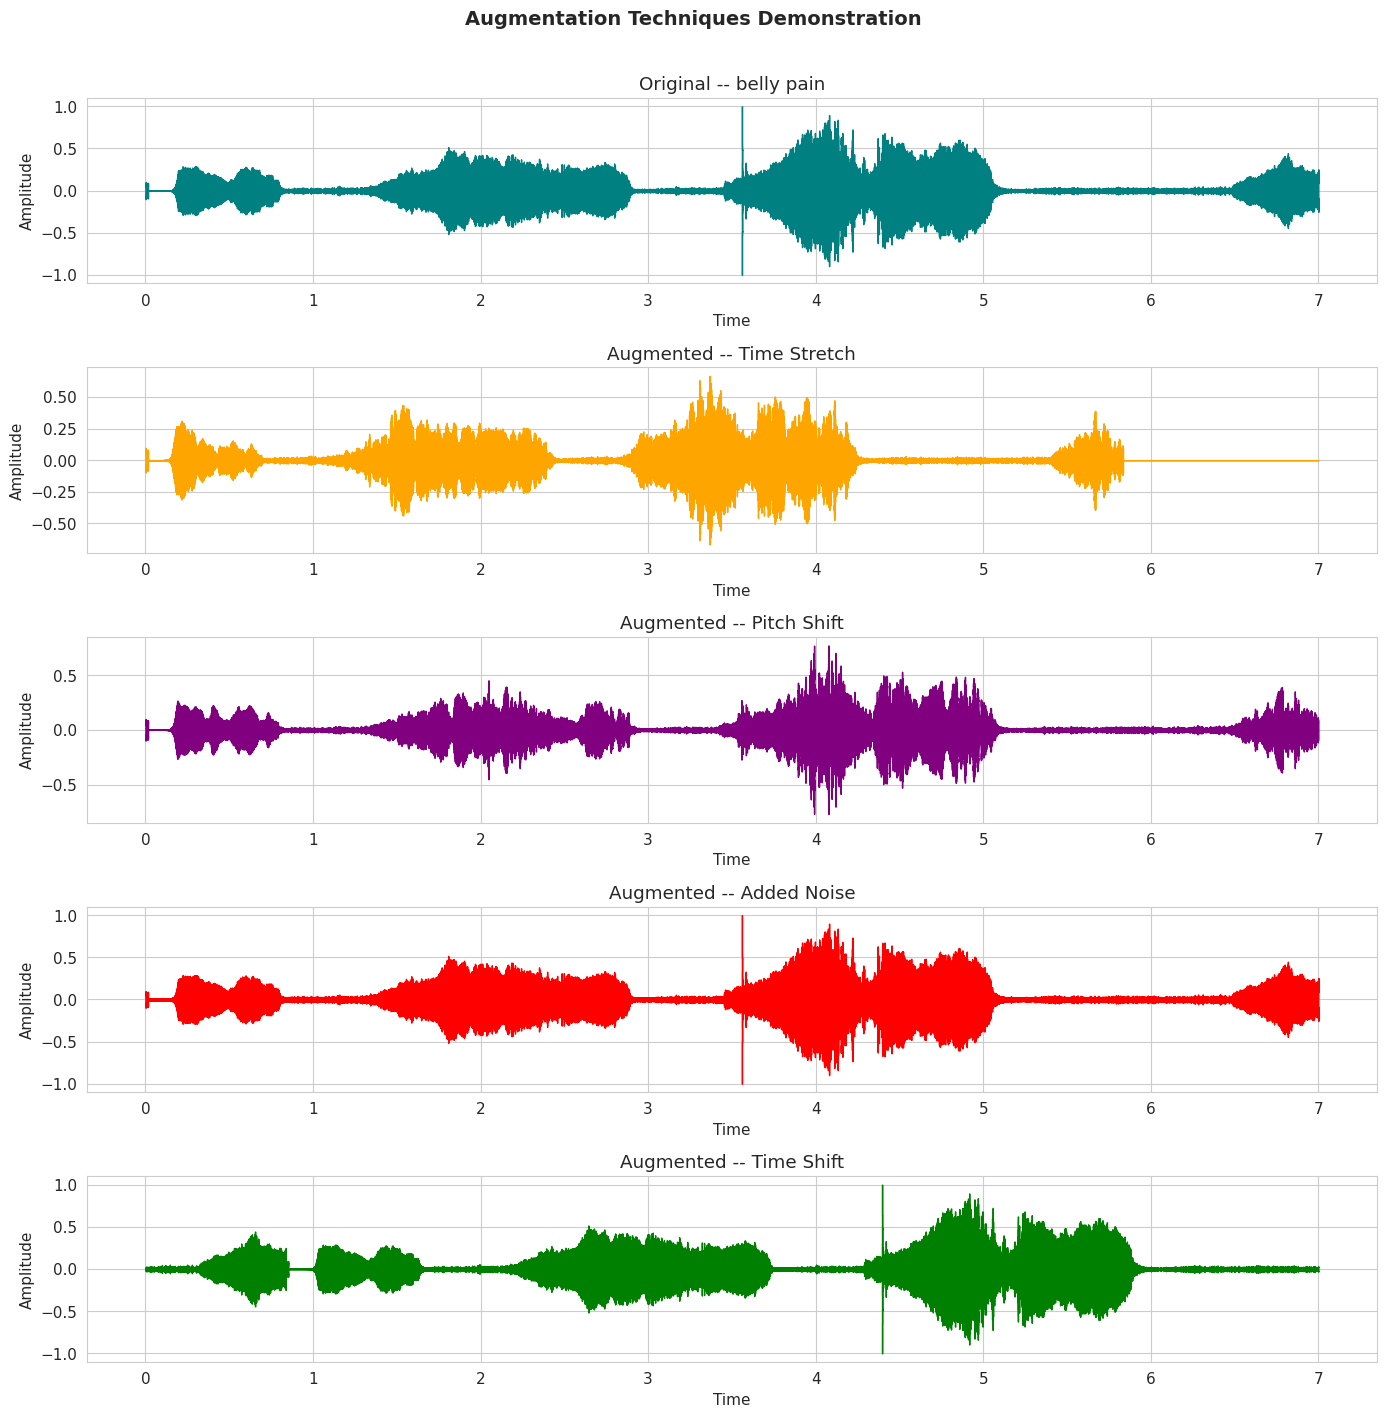

In [192]:
# Visualize augmentation effects on one sample
sample_item = [r for r in qc_results if r['passed_qc']][0]
y_demo = sample_item['audio']

fig, axes = plt.subplots(5, 1, figsize=(14, 14))

librosa.display.waveshow(y_demo, sr=TARGET_SR, ax=axes[0], color='teal')
axes[0].set_title(f'Original -- {sample_item["category"]}')
axes[0].set_ylabel('Amplitude')

aug_funcs = [
    ('Time Stretch', augment_time_stretch),
    ('Pitch Shift', augment_pitch_shift),
    ('Added Noise', augment_add_noise),
    ('Time Shift', augment_time_shift),
]
colors = ['orange', 'purple', 'red', 'green']

for i, (name, func) in enumerate(aug_funcs):
    y_aug = func(y_demo.copy())
    librosa.display.waveshow(y_aug, sr=TARGET_SR, ax=axes[i+1], color=colors[i])
    axes[i+1].set_title(f'Augmented -- {name}')
    axes[i+1].set_ylabel('Amplitude')

plt.suptitle('Augmentation Techniques Demonstration',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [193]:
# Collect all QC-passed samples
clean_audio = [r for r in qc_results if r['passed_qc']]
clean_counts_before = Counter([r['category'] for r in clean_audio])

print("CLASS DISTRIBUTION BEFORE AUGMENTATION")
print("=" * 55)
for cat in sorted(clean_counts_before.keys()):
    count = clean_counts_before[cat]
    needed = max(0, MIN_SAMPLES_PER_CLASS - count)
    status = f"needs {needed} more" if needed > 0 else "sufficient"
    print(f"  {cat:>15s}: {count:>4d}  ({status})")

CLASS DISTRIBUTION BEFORE AUGMENTATION
       belly pain:  133  (sufficient)
          burping:  124  (needs 6 more)
         cold_hot:  130  (sufficient)
       discomfort:  142  (sufficient)
           hungry:  397  (sufficient)
           lonely:   24  (needs 106 more)
           scared:   33  (needs 97 more)
            tired:  142  (sufficient)


In [194]:
if AUGMENT_MINORITY:
    augmented_samples = []
    augmentation_log = []

    for cat in sorted(clean_counts_before.keys()):
        current = clean_counts_before[cat]
        needed = MIN_SAMPLES_PER_CLASS - current

        if needed <= 0:
            continue

        print(f"\nAugmenting {cat}: generating {needed} samples...")

        cat_originals = [r for r in clean_audio if r['category'] == cat]

        for i in tqdm(range(needed), desc=f"  {cat}"):
            source = np.random.choice(cat_originals)
            y_aug, aug_type = apply_random_augmentation(
                source['audio'].copy()
            )

            # Ensure correct length and re-normalize
            if len(y_aug) != TARGET_SAMPLES:
                if len(y_aug) < TARGET_SAMPLES:
                    y_aug = np.pad(y_aug,
                                   (0, TARGET_SAMPLES - len(y_aug)),
                                   mode='constant')
                else:
                    y_aug = y_aug[:TARGET_SAMPLES]

            peak = np.max(np.abs(y_aug))
            if peak > 0:
                y_aug = y_aug / (peak + EPSILON)

            aug_name = f"aug_{cat.replace(' ', '_')}_{i:04d}_{aug_type}.wav"

            augmented_samples.append({
                'file_name': aug_name,
                'category': cat,
                'original_sr': TARGET_SR,
                'passed_qc': True,
                'fail_reason': 'none',
                'audio': y_aug
            })

            augmentation_log.append({
                'new_file': aug_name,
                'source': source['file_name'],
                'category': cat,
                'technique': aug_type
            })

    # Combine original clean + augmented
    all_clean = clean_audio + augmented_samples
    df_aug_log = pd.DataFrame(augmentation_log)

    print(f"\nAugmentation complete:")
    print(f"  Original clean: {len(clean_audio)}")
    print(f"  Augmented:      {len(augmented_samples)}")
    print(f"  Total:          {len(all_clean)}")
else:
    all_clean = clean_audio
    augmented_samples = []
    df_aug_log = pd.DataFrame()
    print("Augmentation disabled.")


Augmenting burping: generating 6 samples...


  burping: 100%|██████████| 6/6 [00:00<00:00, 37.10it/s]



Augmenting lonely: generating 106 samples...


  lonely: 100%|██████████| 106/106 [00:02<00:00, 38.96it/s]



Augmenting scared: generating 97 samples...


  scared: 100%|██████████| 97/97 [00:02<00:00, 40.51it/s]


Augmentation complete:
  Original clean: 1125
  Augmented:      209
  Total:          1334



CLASS DISTRIBUTION AFTER AUGMENTATION
         Category | Original | Augmented | Total
  --------------------------------------------------
       belly pain |      133 |         0 |   133
          burping |      124 |         6 |   130
         cold_hot |      130 |         0 |   130
       discomfort |      142 |         0 |   142
           hungry |      397 |         0 |   397
           lonely |       24 |       106 |   130
           scared |       33 |        97 |   130
            tired |      142 |         0 |   142


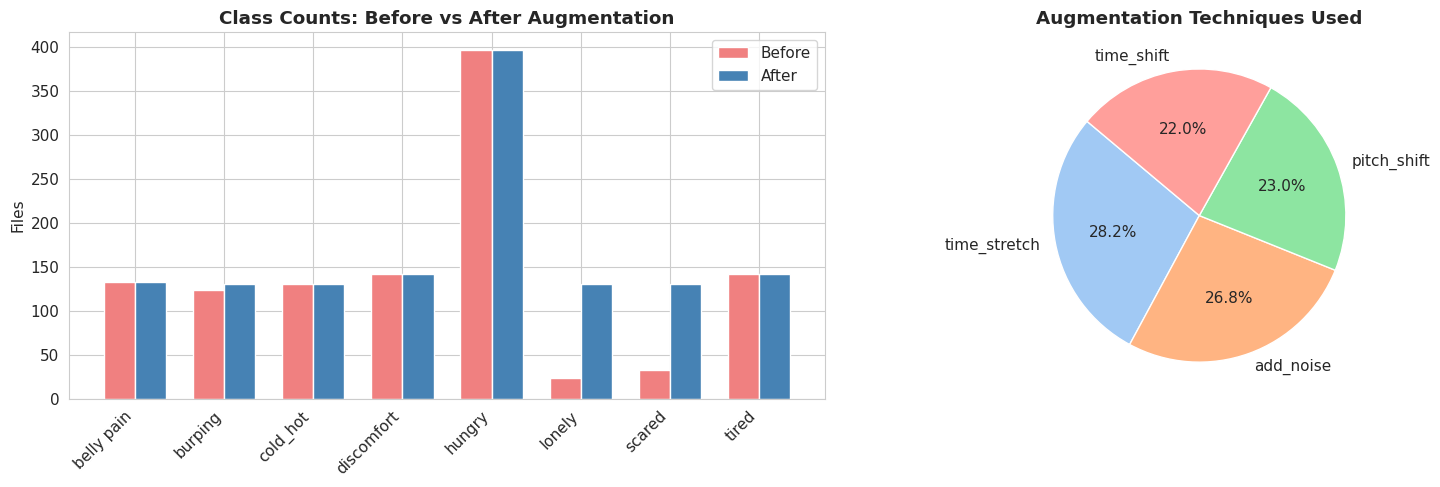

In [195]:
# Class distribution after augmentation
final_counts = Counter([r['category'] for r in all_clean])

print("\nCLASS DISTRIBUTION AFTER AUGMENTATION")
print("=" * 55)
print(f"  {'Category':>15s} | {'Original':>8s} | {'Augmented':>9s} | {'Total':>5s}")
print(f"  {'-' * 50}")
for cat in sorted(final_counts.keys()):
    orig = clean_counts_before.get(cat, 0)
    aug = final_counts[cat] - orig
    print(f"  {cat:>15s} | {orig:>8d} | {aug:>9d} | {final_counts[cat]:>5d}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cats = sorted(final_counts.keys())
before_vals = [clean_counts_before.get(c, 0) for c in cats]
after_vals = [final_counts[c] for c in cats]
x = np.arange(len(cats))
w = 0.35

axes[0].bar(x - w/2, before_vals, w, label='Before', color='lightcoral')
axes[0].bar(x + w/2, after_vals, w, label='After', color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cats, rotation=45, ha='right')
axes[0].set_title('Class Counts: Before vs After Augmentation',
                  fontweight='bold')
axes[0].set_ylabel('Files')
axes[0].legend()

if len(df_aug_log) > 0:
    tech_counts = df_aug_log['technique'].value_counts()
    axes[1].pie(tech_counts.values, labels=tech_counts.index,
                autopct='%1.1f%%', startangle=140,
                colors=sns.color_palette('pastel'))
    axes[1].set_title('Augmentation Techniques Used', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No augmentation',
                 ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

### Augmentation Limitation -- High Synthetic Ratio for Minority Classes

The lonely class required 107 augmented samples generated from
only 24 originals (4.42x multiplier), meaning 82% of the lonely
class is synthetic. The scared class required 97 augmented samples
from 33 originals (2.94x multiplier), meaning 75% of scared class
is synthetic.

This high augmentation ratio is an inherent limitation of the
dataset's severe class imbalance (15.9:1 ratio identified in EDA).
The following implications must be acknowledged during modeling:

1. Per-class F1-score for lonely and scared should be interpreted
   with caution -- high scores may reflect augmentation pattern
   memorization rather than genuine acoustic learning.
2. Grad-CAM analysis in Phase 2 must verify the CNN is attending
   to genuine cry frequency bands rather than augmentation artifacts
   for these two classes.
3. This limitation will be explicitly reported in the ablation
   table and failure analysis sections.

## Section 10 -- Save Cleaned Audio and Manifest

Save all QC-passed files (original + augmented) to the processed
directory with class subfolders. Generate the manifest CSV that
the feature engineering notebook reads.

Output structure:
data/processed/
clean_manifest.csv
audio_clean/
belly pain/
burping/
cold_hot/
discomfort/
hungry/
lonely/
scared/
tired/

In [196]:
# Create category subdirectories
categories = sorted(set([r['category'] for r in all_clean]))
for cat in categories:
    os.makedirs(os.path.join(PROCESSED_DIR, cat), exist_ok=True)

print(f"Created {len(categories)} subdirectories in {PROCESSED_DIR}")

Created 8 subdirectories in data/processed/audio_clean/


In [197]:
# Save all clean audio files
manifest_records = []
save_failures = []

for item in tqdm(all_clean, desc="Saving cleaned audio"):
    try:
        output_path = os.path.join(PROCESSED_DIR, item['category'],
                                    item['file_name'])
        sf.write(output_path, item['audio'], TARGET_SR)

        manifest_records.append({
            'file_path': output_path,
            'file_name': item['file_name'],
            'category': item['category'],
            'sample_rate': TARGET_SR,
            'duration_sec': TARGET_DURATION,
            'num_samples': TARGET_SAMPLES,
            'is_augmented': item['file_name'].startswith('aug_')
        })

    except Exception as e:
        save_failures.append({
            'file': item['file_name'],
            'error': str(e)
        })

df_manifest = pd.DataFrame(manifest_records)

print(f"\nSaved: {len(manifest_records)} files")
print(f"Failed: {len(save_failures)}")
if save_failures:
    for f in save_failures:
        print(f"  {f['file']}: {f['error']}")

Saving cleaned audio: 100%|██████████| 1334/1334 [00:10<00:00, 125.27it/s]


Saved: 1334 files
Failed: 0


In [198]:
# Save manifest CSV
df_manifest.to_csv(MANIFEST_PATH, index=False)
print(f"Manifest saved: {MANIFEST_PATH}")
print(f"  Total entries: {len(df_manifest)}")
print(f"  Original:  {(~df_manifest['is_augmented']).sum()}")
print(f"  Augmented: {df_manifest['is_augmented'].sum()}")

# Save augmentation log
if len(df_aug_log) > 0:
    aug_log_path = os.path.join(os.path.dirname(MANIFEST_PATH),
                                 'augmentation_log.csv')
    df_aug_log.to_csv(aug_log_path, index=False)
    print(f"  Augmentation log: {aug_log_path}")

Manifest saved: data/processed/clean_manifest.csv
  Total entries: 1334
  Original:  1125
  Augmented: 209
  Augmentation log: data/processed/augmentation_log.csv


In [199]:
# Save preprocessing parameters for reproducibility
params = {
    'target_sr': TARGET_SR,
    'target_duration': TARGET_DURATION,
    'target_samples': TARGET_SAMPLES,
    'amplitude_threshold': AMPLITUDE_THRESHOLD,
    'epsilon': EPSILON,
    'augment_minority': AUGMENT_MINORITY,
    'min_samples_per_class': MIN_SAMPLES_PER_CLASS,
    'total_raw_files': len(df_raw),
    'total_valid_files': len(df_valid),
    'total_passed_qc': total_passed,
    'total_after_augmentation': len(all_clean),
    'total_saved': len(manifest_records)
}

with open(PARAMS_PATH, 'w') as f:
    json.dump(params, f, indent=2)
print(f"Parameters saved: {PARAMS_PATH}")
print(json.dumps(params, indent=2))

Parameters saved: data/processed/preprocessing_params.json
{
  "target_sr": 22050,
  "target_duration": 7.0,
  "target_samples": 154350,
  "amplitude_threshold": 0.01,
  "epsilon": 1e-09,
  "augment_minority": true,
  "min_samples_per_class": 130,
  "total_raw_files": 1126,
  "total_valid_files": 1126,
  "total_passed_qc": 1125,
  "total_after_augmentation": 1334,
  "total_saved": 1334
}


## Section 11 -- Verification

Reload every saved file and verify it matches the expected
properties. This catches any saving errors, file corruption,
or parameter mismatches.

In [200]:
verify_passed = 0
verify_failed = 0
verify_errors = []

for _, row in tqdm(df_manifest.iterrows(), total=len(df_manifest),
                   desc="Verifying saved files"):
    try:
        y, sr = librosa.load(row['file_path'], sr=None)

        issues = []
        if sr != TARGET_SR:
            issues.append(f"sr={sr}")
        if len(y) != TARGET_SAMPLES:
            issues.append(f"samples={len(y)}")
        if np.any(np.isnan(y)):
            issues.append("NaN")
        if np.any(np.isinf(y)):
            issues.append("Inf")

        if issues:
            verify_failed += 1
            verify_errors.append({
                'file': row['file_path'],
                'issues': '; '.join(issues)
            })
        else:
            verify_passed += 1

    except Exception as e:
        verify_failed += 1
        verify_errors.append({
            'file': row['file_path'],
            'issues': str(e)
        })

print(f"\nVERIFICATION RESULTS")
print(f"=" * 55)
print(f"  Passed: {verify_passed}")
print(f"  Failed: {verify_failed}")

if verify_errors:
    print(f"\n  Errors:")
    for err in verify_errors[:10]:
        print(f"    {err['file']}: {err['issues']}")

if verify_failed == 0:
    print(f"\n  All {verify_passed} files verified successfully.")

Verifying saved files: 100%|██████████| 1334/1334 [00:01<00:00, 1317.91it/s]


VERIFICATION RESULTS
  Passed: 1334
  Failed: 0

  All 1334 files verified successfully.


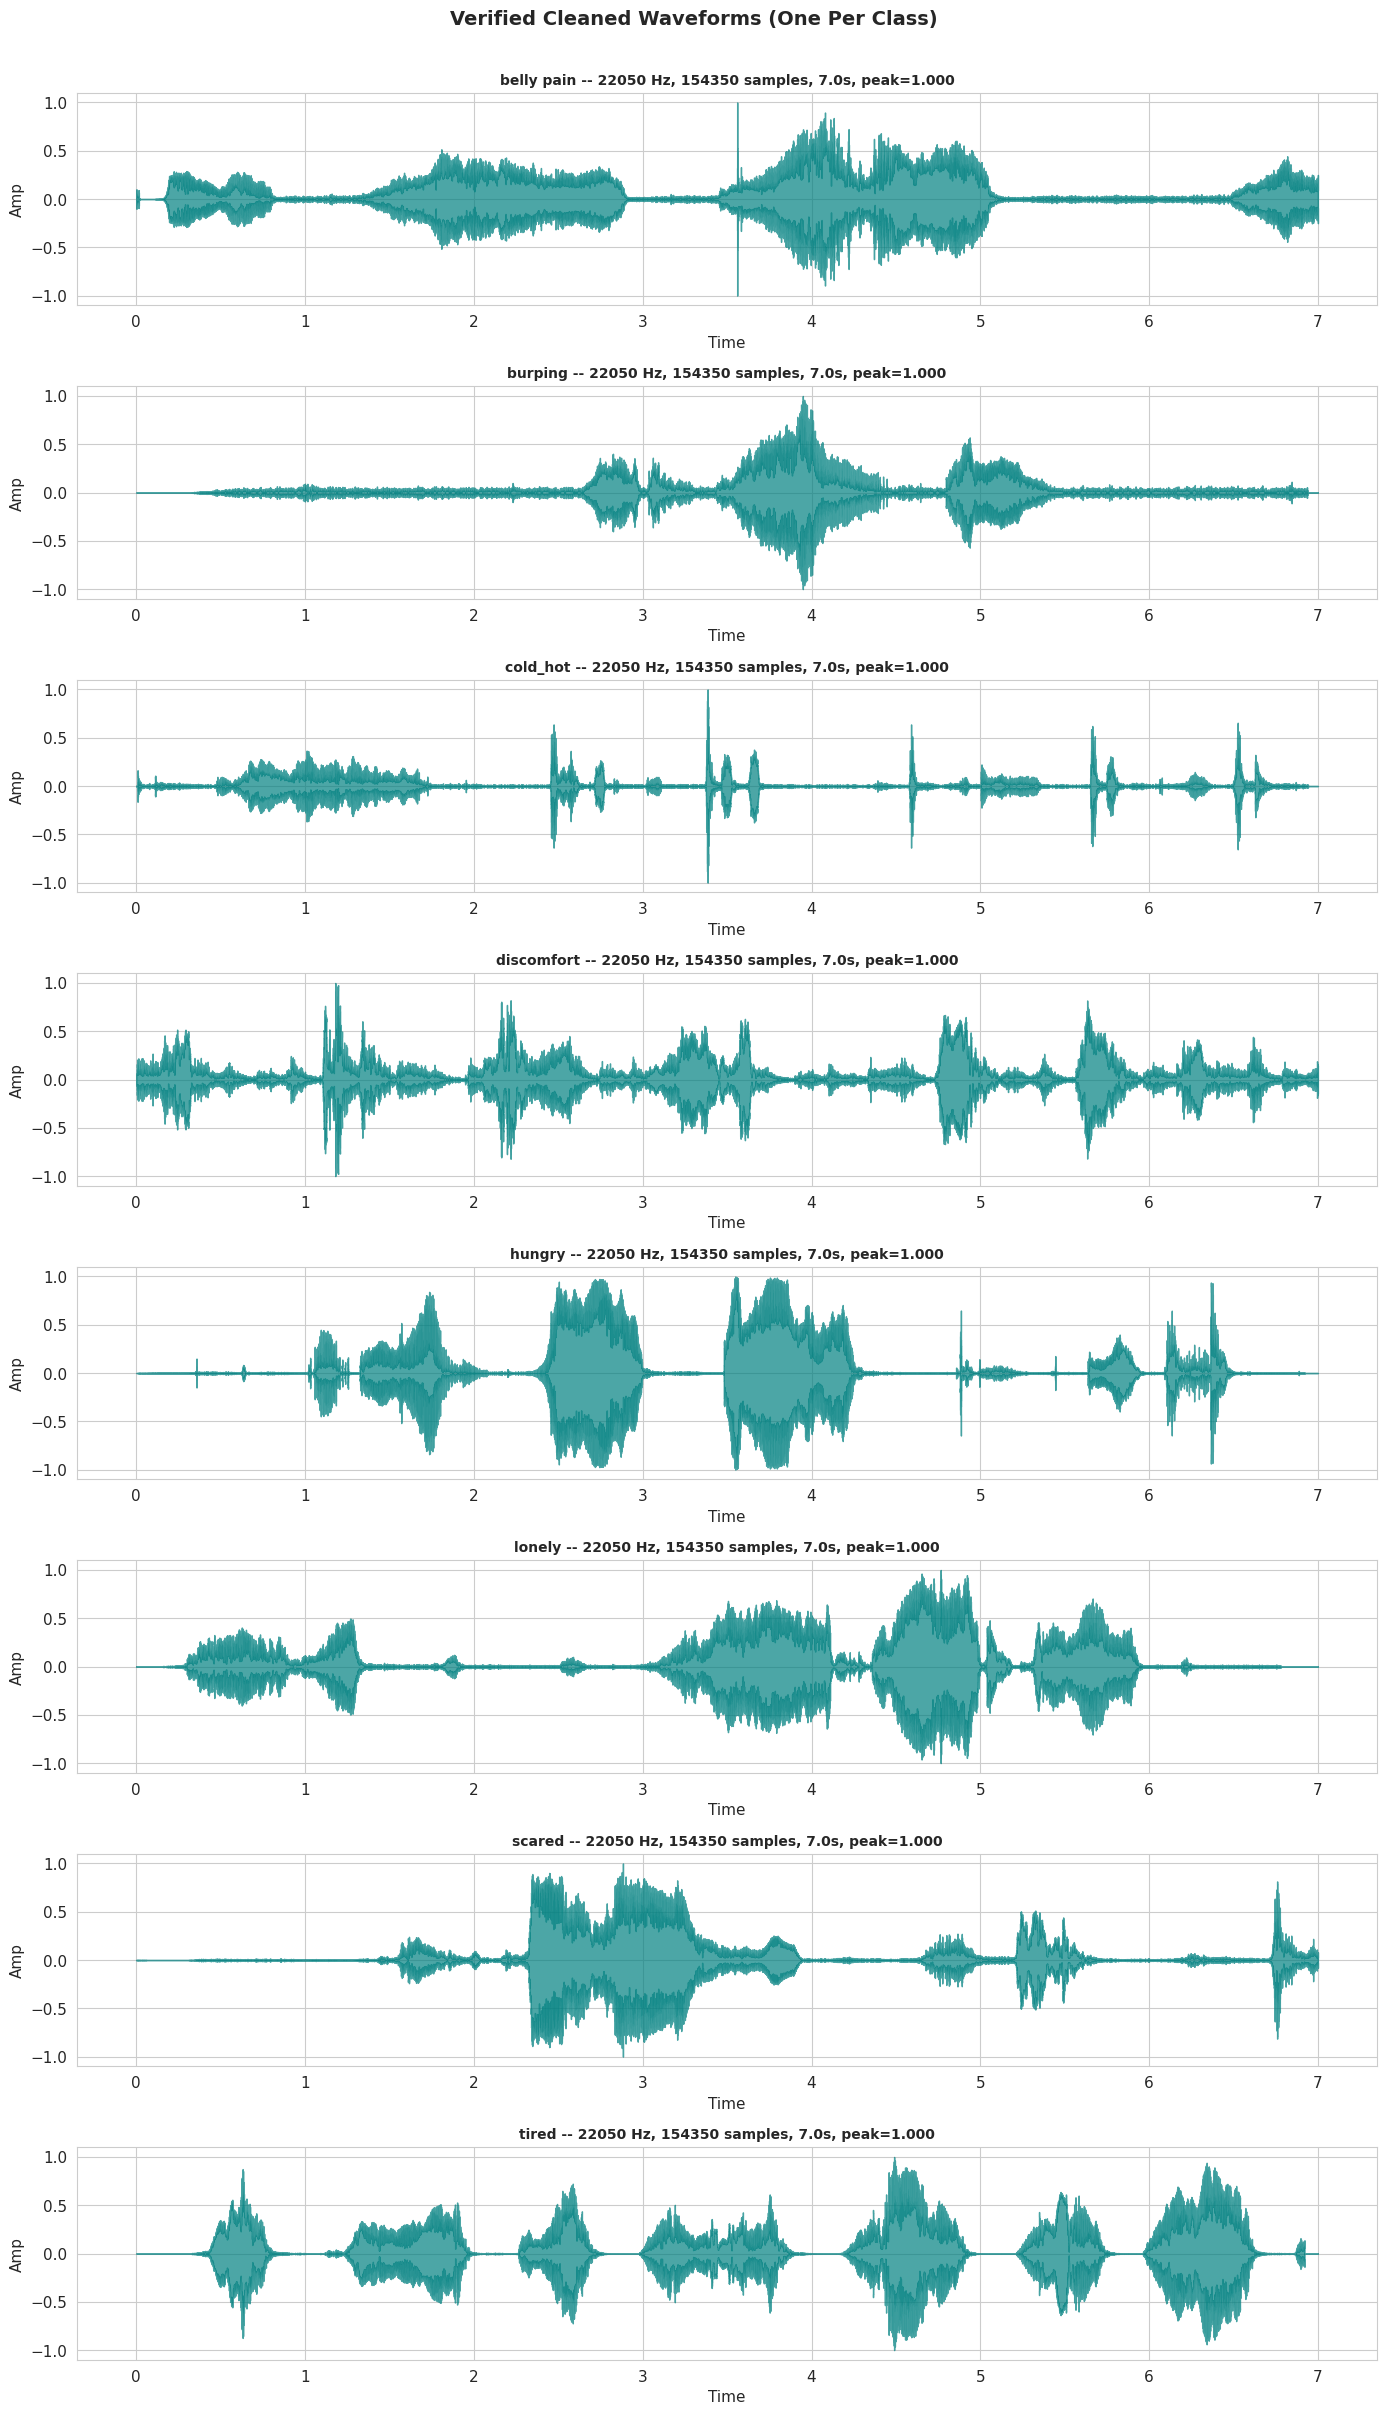

In [201]:
# Visual verification: one waveform per class from saved files
fig, axes = plt.subplots(len(categories), 1,
                         figsize=(14, 3 * len(categories)))

for idx, cat in enumerate(categories):
    cat_files = df_manifest[df_manifest['category'] == cat]
    sample_path = cat_files.iloc[0]['file_path']
    y, sr = librosa.load(sample_path, sr=None)

    librosa.display.waveshow(y, sr=sr, ax=axes[idx], color='teal', alpha=0.7)
    axes[idx].set_title(
        f'{cat} -- {sr} Hz, {len(y)} samples, '
        f'{len(y)/sr:.1f}s, peak={np.max(np.abs(y)):.3f}',
        fontweight='bold', fontsize=10
    )
    axes[idx].set_ylabel('Amp')
    axes[idx].set_ylim(-1.1, 1.1)

plt.suptitle('Verified Cleaned Waveforms (One Per Class)',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

## Section 12 -- Final Summary

In [202]:
# Clean up temp directory
if os.path.exists(TEMP_DIR):
    shutil.rmtree(TEMP_DIR)
    print(f"Cleaned up: {TEMP_DIR}")

Cleaned up: data/temp_converted/


In [203]:
# Compute disk usage
total_bytes = 0
for cat in categories:
    cat_dir = os.path.join(PROCESSED_DIR, cat)
    if os.path.exists(cat_dir):
        for f in os.listdir(cat_dir):
            fp = os.path.join(cat_dir, f)
            if os.path.isfile(fp):
                total_bytes += os.path.getsize(fp)

total_mb = total_bytes / (1024 * 1024)

In [204]:
raw_counts = df_raw['category'].value_counts()
clean_counts = df_manifest['category'].value_counts()
aug_counts = df_manifest[df_manifest['is_augmented']]['category'].value_counts()

print("=" * 65)
print("PREPROCESSING PIPELINE -- FINAL SUMMARY")
print("=" * 65)

print(f"\n  TRACEABILITY")
print(f"  {'-' * 55}")
print(f"  Raw files loaded:         {len(df_raw)}")
print(f"  Failed raw validation:    {len(invalid_records)}")
print(f"  Non-.wav converted:       {len(converted)}")
print(f"  Conversion failures:      {len(conversion_failures)}")
print(f"  Passed QC:                {total_passed}")
print(f"  Failed QC:                {total_failed}")
print(f"  Augmented samples added:  {len(augmented_samples)}")
print(f"  Final saved files:        {len(df_manifest)}")
print(f"  Verification passed:      {verify_passed}")
print(f"  Verification failed:      {verify_failed}")

print(f"\n  PER-CLASS FILE COUNTS")
print(f"  {'-' * 60}")
print(f"  {'Category':>15s} | {'Raw':>4s} | {'QC Pass':>7s} | "
      f"{'Augmented':>9s} | {'Final':>5s}")
print(f"  {'-' * 60}")

for cat in sorted(categories):
    raw = raw_counts.get(cat, 0)
    qc_pass = clean_counts_before.get(cat, 0)
    aug = int(aug_counts.get(cat, 0))
    final = int(clean_counts.get(cat, 0))
    print(f"  {cat:>15s} | {raw:>4d} | {qc_pass:>7d} | "
          f"{aug:>9d} | {final:>5d}")

total_raw = sum(raw_counts.values)
total_qc = sum(clean_counts_before.values())
total_aug = int(aug_counts.sum()) if len(aug_counts) > 0 else 0
total_final = int(clean_counts.sum())

print(f"  {'-' * 60}")
print(f"  {'TOTAL':>15s} | {total_raw:>4d} | {total_qc:>7d} | "
      f"{total_aug:>9d} | {total_final:>5d}")

print(f"\n  AUDIO PROPERTIES (all saved files)")
print(f"  {'-' * 40}")
print(f"  Sample rate:   {TARGET_SR} Hz")
print(f"  Duration:      {TARGET_DURATION} s")
print(f"  Samples:       {TARGET_SAMPLES}")
print(f"  Channels:      1 (mono)")
print(f"  Format:        .wav")
print(f"  Amplitude:     peak-normalized to 1.0")
print(f"  Disk usage:    {total_mb:.1f} MB")

print(f"\n  OUTPUT FILES")
print(f"  {'-' * 40}")
print(f"  Manifest:    {MANIFEST_PATH}")
print(f"  Audio dir:   {PROCESSED_DIR}")
print(f"  Parameters:  {PARAMS_PATH}")


PREPROCESSING PIPELINE -- FINAL SUMMARY

  TRACEABILITY
  -------------------------------------------------------
  Raw files loaded:         1126
  Failed raw validation:    0
  Non-.wav converted:       87
  Conversion failures:      0
  Passed QC:                1125
  Failed QC:                1
  Augmented samples added:  209
  Final saved files:        1334
  Verification passed:      1334
  Verification failed:      0

  PER-CLASS FILE COUNTS
  ------------------------------------------------------------
         Category |  Raw | QC Pass | Augmented | Final
  ------------------------------------------------------------
       belly pain |  133 |     133 |         0 |   133
          burping |  124 |     124 |         6 |   130
         cold_hot |  130 |     130 |         0 |   130
       discomfort |  142 |     142 |         0 |   142
           hungry |  397 |     397 |         0 |   397
           lonely |   25 |      24 |       106 |   130
           scared |   33 |      33 